**Data Visualization: Looking at the t-SNE plot with different qualities**
*date created: 08.19.2026*\
*database in use: apkr_reactions.db*\
**what to vizualize:**
1. frequency of specific precursor used (how many time has an ether enyne been used?)
2. colored based on ee (which precursors are easier to get good ee from?)
3. colored based on yield (which precursors are easier to get high yield?)


In [86]:
from pathlib import Path
from database_commands import update_database, troubleshooting, clean_slate
import sqlite3
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re

database_name = 'apkr_reactions.db'

now = datetime.now()
timestamp_string = now.strftime("%m.%d.%Y")
print(timestamp_string)

08.24.2026


In [3]:
# Checks if all the current excel sheets have been added to the 'all_data' table 
data_path = Path("../0.database_excels/")       # directory where excel sheets are located
sheet_list = [f.name for f in data_path.iterdir() if f.is_file()]
sheet_list.remove('template.xlsx')

conn = sqlite3.connect(database_name)
cur = conn.cursor()

cur.execute("SELECT sheet_name FROM added_sheets")
already_added = {row[0] for row in cur.fetchall()}
conn.close()

yet_to_upload = []
for entry in sheet_list:
    if entry not in already_added:
        yet_to_upload.append(entry)

if yet_to_upload:
    print("Not yet in database:", sorted(yet_to_upload))
    update_database(sheet_list=yet_to_upload)
else:
    print("Good to go! All sheets are in database.")

conn = sqlite3.connect(database_name)
cur = conn.cursor()
cur.execute("SELECT COUNT(*) FROM all_data")
reaction_num = cur.fetchone()[0]
conn.close()
print(f'{reaction_num} in database.')

Good to go! All sheets are in database.
623 in database.


In [4]:
conn = sqlite3.connect(database_name)
cur = conn.cursor()

columns = [row[1] for row in cur.execute("PRAGMA table_info(all_data)")]
print(columns)

conn.close()

['DOI', 'Figure/Table', 'Entry', 'Substrate SMILES', 'Substrate cpd #', 'Rh precatalyst', 'Rh precat. loading (mol %)', 'Ligand name', 'Ligand SMILES', 'Ligand loading (mol %)', 'Ligand cpd #', 'Solvent', 'Reaction run time', 'Product SMILES', 'Product cpd #', 'Byproduct SMILES', 'Byproduct cpd #', '% yield (product)', '% yield type (product)', '% ee (product)', 'dr (product)', '% yield (byproduct)', '% yield type (byproduct)', '% ee (byproduct)', 'Method of % ee', '% recovered SM', 'Notes', 'canonical_sub_smiles']


**Visualizing Enyne Use Frequency**

In [ ]:
# Visualizes how often enynes have been used

# adds a canonicalized SMILES column to all_data
conn = sqlite3.connect(database_name)
cur = conn.cursor()

if 'canonical_sub_smiles' not in columns:
    cur.execute("ALTER TABLE all_data ADD COLUMN canonical_sub_smiles TEXT")
rows = cur.execute('SELECT rowid, "Substrate SMILES" FROM all_data').fetchall()
for rowid, smi in rows:
    mol = Chem.MolFromSmiles(smi)
    canon = Chem.MolToSmiles(mol) if mol else None
    cur.execute('UPDATE all_data SET canonical_sub_smiles = ? WHERE rowid = ?', (canon, rowid))
conn.commit()

# Identify unique canonical SMILES and number them
cur.execute(''' 
    SELECT canonical_sub_smiles, COUNT (*) AS n
    FROM all_data
    GROUP BY canonical_sub_smiles
    ORDER BY n DESC
    ''')

smiles_list = []
frequency = []

for smiles, n in cur.fetchall():
    smiles_list.append(smiles)
    frequency.append(n)
conn.close()

freq_label = {"sub_smiles": smiles_list, "frequency": frequency}
freq_label_df = pd.DataFrame(freq_label)
print(freq_label_df.head())

##########################################################################
# Visualization 



                                   sub_smiles  frequency
0                           C=CCOCC#Cc1ccccc1        102
1            CC(=O)OC=C=C(C)CCCC#C[Si](C)(C)C         39
2     C=CCN(CC#Cc1ccccc1)S(=O)(=O)c1ccc(C)cc1         32
3       C=CC(C=C)N(CC#CC)S(=O)(=O)c1ccc(C)cc1         27
4  C=C(C)CN(CC#Cc1ccccc1)S(=O)(=O)c1ccc(C)cc1         27


In [21]:
# Makes freq_label_df to create plot
# tsne_data = f"tsne_{timestamp_string}"
tsne_data = 'cluster_08.19.2026.csv'

tsne_df = pd.read_csv(tsne_data)
# print(tsne_df.head())

# Plots t-SNE but changes size of enyne point based on the requency in the database
# maps sqrt(frequency) onto a sensible pixel range
freq = np.asarray(freq_label_df["frequency"])
# print(freq)

X = []
Y = []
labels = []
# records coord values of TSNE1 and TSNE2
for s in freq_label_df['sub_smiles']:
    tsne1 = tsne_df.loc[tsne_df['smiles'] == s, 'tsne_1'].item()
    tsne2 = tsne_df.loc[tsne_df['smiles'] == s, 'tnse_2'].item() #'tnse_2' because mistyped when generating csv
    label = tsne_df.loc[tsne_df['smiles'] == s, 'cluster'].item()
    X.append(tsne1)
    Y.append(tsne2)
    labels.append(label)

# add X and Y values to freq_label_df
freq_label_df['TSNE1'] = X
freq_label_df['TSNE2'] = Y
freq_label_df['labels'] = labels
print(freq_label_df.head())


                                   sub_smiles  frequency     TSNE1      TSNE2  \
0                           C=CCOCC#Cc1ccccc1        102  5.614561  -2.307301   
1            CC(=O)OC=C=C(C)CCCC#C[Si](C)(C)C         39  4.507067 -14.519766   
2     C=CCN(CC#Cc1ccccc1)S(=O)(=O)c1ccc(C)cc1         32 -4.166568  17.008743   
3       C=CC(C=C)N(CC#CC)S(=O)(=O)c1ccc(C)cc1         27 -3.622684  13.494076   
4  C=C(C)CN(CC#Cc1ccccc1)S(=O)(=O)c1ccc(C)cc1         27 -7.849796  16.265244   

   labels  
0       7  
1       2  
2       0  
3       0  
4       0  


In [33]:
# ----------------------------------------------------------------------
# Size mapping
# ----------------------------------------------------------------------
# matplotlib's `s` is marker AREA in points^2, so scale sqrt(frequency)
# to keep perceived area proportional to the count.
S_COEF = 50          # raise for bigger points overall
S_FLOOR = 1         # minimum area, so frequency == 1 is still visible
 
 
def freq_to_size(freq):
    return S_FLOOR + S_COEF * np.sqrt(np.asarray(freq, dtype=float))
 
 
def size_to_freq(s):
    """Inverse of freq_to_size, for labelling the size legend."""
    return ((np.asarray(s, dtype=float) - S_FLOOR) / S_COEF) ** 2
 
 
def size_legend_ticks(freq, n=4):
    """Pick up to `n` round frequency values spanning the observed range."""
    lo, hi = int(np.min(freq)), int(np.max(freq))
    if lo == hi:
        return [lo]
    raw = np.linspace(lo, hi, n)
    ticks = []
    for v in raw:
        step = 10 ** max(0, int(np.floor(np.log10(max(v, 1)))))
        ticks.append(max(lo, int(round(v / step) * step)))
    return sorted(set(ticks))
 
 
# ----------------------------------------------------------------------
# Plot
# ----------------------------------------------------------------------
def plot_clusters(df, title=None, figsize=(6.0, 9.0), annotate=True):
    clustered = df[df["labels"] != -1]
    noise = df[df["labels"] == -1]
 
    cluster_ids = np.sort(clustered["labels"].unique())
    n_clusters = len(cluster_ids)
 
    # tab20 pairs dark/light shades, which is what gives the original its look
    palette = plt.get_cmap("tab20")
    colors = {cid: palette(i % 20) for i, cid in enumerate(cluster_ids)}
 
    fig, ax = plt.subplots(figsize=figsize)
 
    # noise first, underneath everything
    if len(noise):
        ax.scatter(
            noise["TSNE1"], noise["TSNE2"],
            s=freq_to_size(noise["frequency"]),
            marker="x", c="0.75", linewidths=1.0, zorder=1,
        )
 
    # big markers first so small ones are not buried
    order = clustered.sort_values("frequency", ascending=False)
    ax.scatter(
        order["TSNE1"], order["TSNE2"],
        s=freq_to_size(order["frequency"]),
        c=[colors[l] for l in order["labels"]],
        alpha=0.85, edgecolors="white", linewidths=0.4, zorder=2,
    )
 
    # cluster ID at the cluster centre (median resists t-SNE stragglers)
    if annotate:
        for cid in cluster_ids:
            sub = clustered[clustered["labels"] == cid]
            ax.annotate(
                str(cid),
                (sub["TSNE1"].median(), sub["TSNE2"].median()),
                fontsize=11, fontweight="bold", color="black",
                ha="center", va="center", zorder=3,
                path_effects=None,
            )
 
    ax.set_xlabel("t-SNE 1", fontsize=12)
    ax.set_ylabel("t-SNE 2", fontsize=12)
    ax.set_title(
        title or f"Substrates: {n_clusters} HDBSCAN clusters",
        fontsize=13, pad=12,
    )
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
 
    # ---- size legend (colorbars are automatic, size legends are not) ----
    # Built by hand: Line2D takes markersize as a DIAMETER in points, while
    # scatter takes `s` as an AREA in points^2, hence the sqrt.
    ticks = size_legend_ticks(df["frequency"])
    handles = [
        Line2D(
            [], [], marker="o", linestyle="none", color="0.45", alpha=0.7,
            markersize=np.sqrt(freq_to_size(f)),
        )
        for f in ticks
    ]
    ax.legend(
        handles, [str(f) for f in ticks], title="frequency", loc="lower left",
        frameon=False, labelspacing=1.6, borderpad=1.0,
        handletextpad=1.2, fontsize=9, title_fontsize=10,
    )
 
    fig.tight_layout()
    return fig, ax

74 singletons
1 frequency
1    74
2    19
3    11
9     4
4     4
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

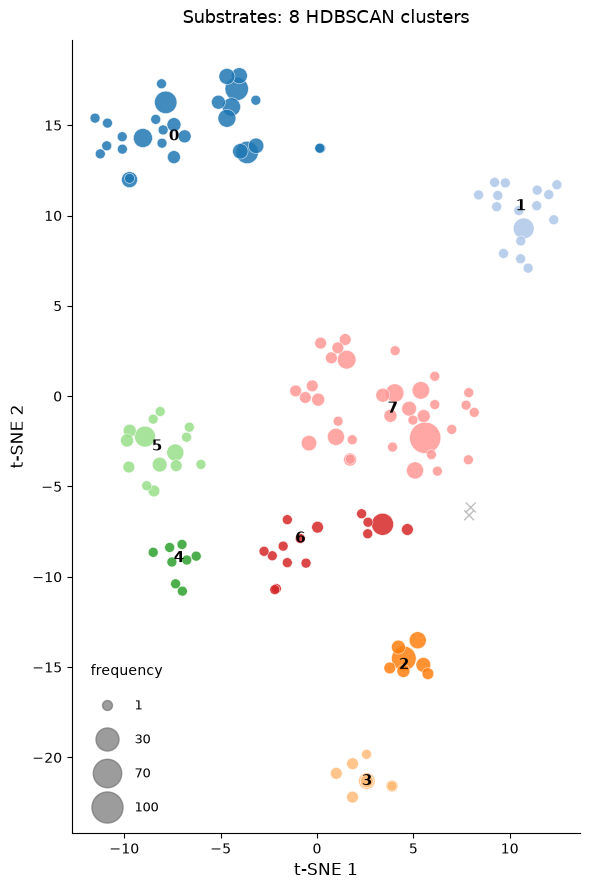

In [39]:
print((freq_label_df["frequency"] == 1).sum(), "singletons")
print(freq_label_df["frequency"].min(), freq_label_df["frequency"].value_counts().head())

# Make frequency plot
fig, ax = plot_clusters(df=freq_label_df)
fig.savefig(f'freq_cluster_{timestamp_string}.png', dpi=300, bbox_inches='tight')
plt.show

**Visualize Highest %ee For Each Enyne**

In [48]:
# pull top %ee for each unique SMILE string
conn = sqlite3.connect(database_name)
cur = conn.cursor()

# Identify unique canonical SMILES and number them
cur.execute(''' 
    SELECT canonical_sub_smiles, MAX("% ee (product)")
    FROM all_data
    GROUP BY canonical_sub_smiles 
    ''')

smiles_list_ee = []
max_ee = []

for smiles, n in cur.fetchall():
    smiles_list_ee.append(smiles)
    
    max_ee.append(n)
conn.close()

ee_data = {"smiles": smiles_list_ee, "max_ee": max_ee}
all_ee_df = pd.DataFrame(ee_data)


In [58]:
# filters out all ee values without a number and isolates the number 
# A leading qualifier, then the number. Anchored at the start so that
# incidental digits later in the string ('on 3-8', '3-7') are never picked up.
_EE = re.compile(r"^\s*(>=|<=|>|<|~|≥|≤)?\s*(\d+(?:\.\d+)?)")
 
# Strings that mean "no value", even though some of them contain digits.
_NO_VALUE = re.compile(
    r"^\s*(n/?\.?a\.?|n\.?d\.?|not\s+(determined|reported))\b", re.I
)
 
_CONFIG = re.compile(r"\(\s*([RS])\s*\)")
 
 
def parse_ee(raw):
    """Return (ee, qualifier, config, status) for one raw string."""
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return None, None, None, "missing"
 
    text = str(raw).strip()
    if not text:
        return None, None, None, "missing"
 
    config = m.group(1) if (m := _CONFIG.search(text)) else None
 
    # Screen out non-values BEFORE looking for digits.
    if _NO_VALUE.match(text):
        # 'n/a (racemic ligand / achiral ligand)' is a real ee of 0 --
        # an achiral ligand gives racemic product by definition.
        if re.search(r"racemic|achiral", text, re.I) and not re.search(
            r"0\s*%\s*yield|trace", text, re.I
        ):
            return 0.0, None, config, "racemic"
        return None, None, config, "not_determined"
 
    if m := _EE.match(text):
        return float(m.group(2)), m.group(1), config, "ok"
 
    # No leading number: 'racemic' on its own is still a measurement.
    if re.fullmatch(r"racemic\.?", text, re.I):
        return 0.0, None, config, "racemic"
 
    return None, None, config, "unparsed"
 
 
def parse_ee_series(values):
    """Parse an iterable of raw strings into a tidy DataFrame."""
    parsed = [parse_ee(v) for v in values]
    return pd.DataFrame(parsed, columns=["ee", "qualifier", "config", "status"]).assign(
        raw=list(values)
    )[["raw", "ee", "qualifier", "config", "status"]]

#################################################################################################
tsne_data = 'cluster_08.19.2026.csv'

tsne_df = pd.read_csv(tsne_data)

ee_df = parse_ee_series(all_ee_df['max_ee'])
ee_df['smiles'] = all_ee_df['smiles']

X_ee = []
Y_ee = []
labels_ee = []

# records coord values of TSNE1 and TSNE2
for s in all_ee_df['smiles']:
    tsne1 = tsne_df.loc[tsne_df['smiles'] == s, 'tsne_1'].item()
    tsne2 = tsne_df.loc[tsne_df['smiles'] == s, 'tnse_2'].item() #'tnse_2' because mistyped when generating csv
    label = tsne_df.loc[tsne_df['smiles'] == s, 'cluster'].item()
    X_ee.append(tsne1)
    Y_ee.append(tsne2)
    labels_ee.append(label)

# add X and Y values to freq_label_df
ee_df['TSNE1'] = X_ee
ee_df['TSNE2'] = Y_ee
ee_df['labels'] = labels_ee

clean = ee_df[ee_df["ee"].notna()]
sort_clean = clean.sort_values(by='labels')
print(sort_clean.head())



       raw    ee qualifier config status  \
3       67  67.0       NaN    NaN     ok   
4     99.6  99.6       NaN    NaN     ok   
19    94.0  94.0       NaN    NaN     ok   
16  95 (S)  95.0       NaN      S     ok   
15    95.0  95.0       NaN    NaN     ok   

                                        smiles     TSNE1      TSNE2  labels  
3         C#CCN(C(C=C)C=C)S(=O)(=O)c1ccc(C)cc1 -3.978734  13.556204       0  
4           C#CCN(CC(=C)C)S(=O)(=O)c1ccc(C)cc1 -6.869193  14.382408       0  
19  C=C(C)CN(CC#Cc1ccccc1)S(=O)(=O)c1ccc(C)cc1 -7.849796  16.265244       0  
16        C=C(C)CN(CC#CCl)S(=O)(=O)c1ccc(C)cc1 -9.034184  14.290861       0  
15         C=C(C)CN(CC#CC)S(=O)(=O)c1ccc(C)cc1 -7.422196  15.029341       0  


(<Figure size 1300x700 with 1 Axes>, <Axes: xlabel='cluster', ylabel='% ee'>)

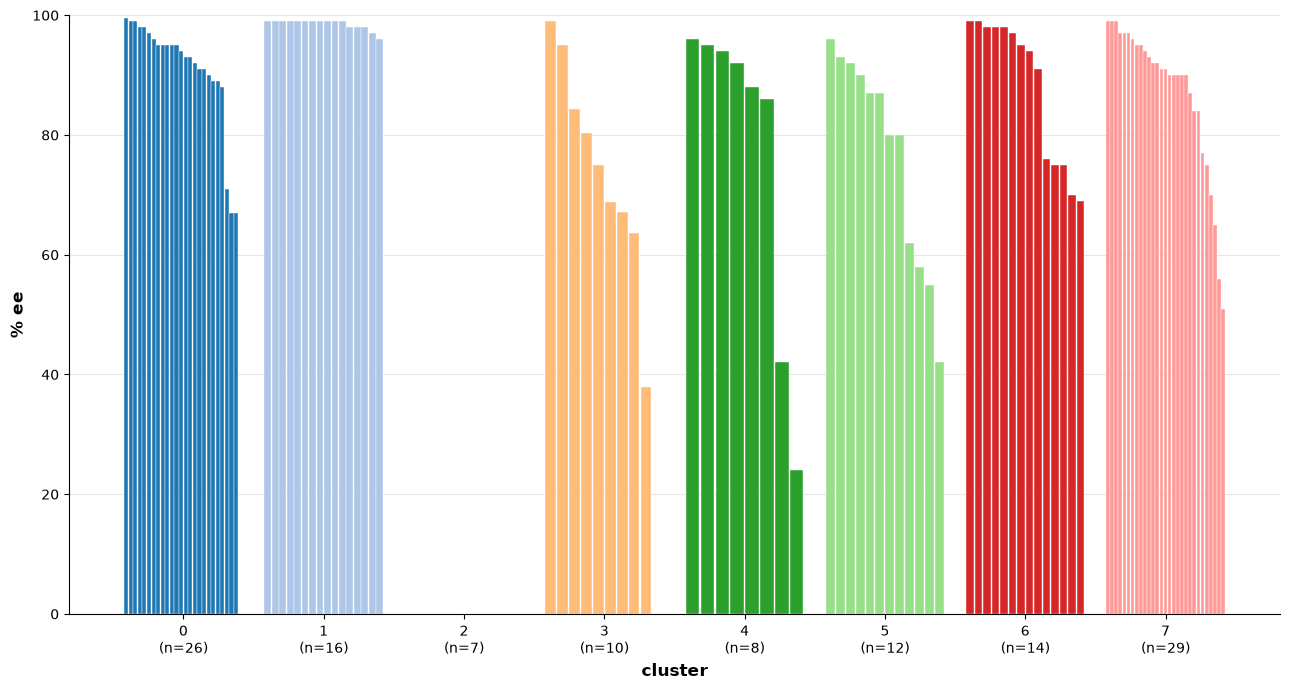

In [78]:
def plot_ee_by_cluster(
    df,
    ee_col="ee",
    label_col="labels",
    group_width=0.85,      # fraction of the slot occupied by bars
    include_noise=False,
    sort_within=True,      # tallest-to-shortest inside each cluster
    figsize=(13, 7),
):
    d = df.dropna(subset=[ee_col]).copy()
    if not include_noise:
        d = d[d[label_col] != -1]
 
    palette = plt.get_cmap("tab20")
    fig, ax = plt.subplots(figsize=figsize)
 
    centres, tick_labels = [], []
 
    # enumerate() rather than the cluster id itself, so non-contiguous ids
    # and the -1 noise group all land in evenly spaced slots
    for slot, (cid, grp) in enumerate(d.groupby(label_col, sort=True)):
        if sort_within:
            grp = grp.sort_values(ee_col, ascending=False)
 
        n = len(grp)
        bar_w = group_width / n
        offsets = (np.arange(n) - (n - 1) / 2) * bar_w
 
        ax.bar(
            slot + offsets,
            grp[ee_col].to_numpy(),
            width=bar_w * 0.9,          # 10% gap between neighbours
            color=palette(int(cid) % 20),
            edgecolor="white",
            linewidth=0.3,
            zorder=2,
        )
 
        centres.append(slot)
        tick_labels.append(f"{cid}\n(n={n})")
 
    ax.set_xticks(centres)
    ax.set_xticklabels(tick_labels)
    ax.set_xlabel("cluster", fontweight="bold", fontsize=12)
    ax.set_ylabel("% ee", fontweight="bold", fontsize=12)
    ax.set_ylim(0, 100)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color="0.9", linewidth=0.8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
 
    fig.tight_layout()
    return fig, ax
 
 
def plot_max_ee_by_cluster(df, ee_col="ee", label_col="labels",
                           include_noise=False, figsize=(8, 6)):
    """One bar per cluster showing the best ee achieved in that cluster."""
    d = df.dropna(subset=[ee_col])
    if not include_noise:
        d = d[d[label_col] != -1]
 
    agg = d.groupby(label_col)[ee_col].agg(["max", "median", "count"])
    palette = plt.get_cmap("tab20")
 
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(agg))
    ax.bar(x, agg["max"], width=0.6,
           color=[palette(int(c) % 20) for c in agg.index],
           edgecolor="white", zorder=2)
    # median as a tick mark, so the max is not read as typical
    ax.scatter(x, agg["median"], marker="_", s=400, color="0.25", zorder=3)
 
    ax.set_xticks(x)
    ax.set_xticklabels([f"{c}\n(n={n})" for c, n in zip(agg.index, agg["count"])])
    ax.set_xlabel("cluster", fontweight="bold", fontsize=12)
    ax.set_ylabel("% ee", fontweight="bold", fontsize=12)
    ax.set_ylim(0, 100)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color="0.9", linewidth=0.8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
 
    fig.tight_layout()
    return fig, ax

plot_ee_by_cluster(sort_clean)